# Movie Recommendation Project 2026
Kaggle prokect link - https://www.kaggle.com/competitions/movie-recommendation-hackathon-2026

## Overview
Description
Challenge Description
In today’s technology-driven world, recommender systems are socially and economically critical for ensuring that individuals can make appropriate choices surrounding the content they engage with on a daily basis. One application where this is especially true surrounds movie content recommendations; where intelligent algorithms can help viewers find great titles from tens of thousands of options.

...ever wondered how Netflix, Amazon Prime, Showmax, Disney and the likes somehow know what to recommend to you?


In [1]:
# import packages
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")
# Entity featurization and similarity computation
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

# Libraries used during sorting procedures.
import operator # <-- Convenient item retrieval during iteration
import heapq # <-- Efficient sorting of large lists

# Imported for our sanity
import warnings
warnings.filterwarnings('ignore')


In [2]:
from pathlib import Path
import pandas as pd

# Try common locations depending on where the notebook kernel starts.
candidate_dirs = [
    Path.cwd() / "data" / "movie-recommendation-hackathon-2026",
    Path.cwd().parent / "data" / "movie-recommendation-hackathon-2026",
    Path("..") / "data" / "movie-recommendation-hackathon-2026",
]

data_dir = next((p for p in candidate_dirs if p.exists()), None)
if data_dir is None:
    raise FileNotFoundError("Could not locate data/movie-recommendation-hackathon-2026")

train_df = pd.read_csv(data_dir / "train.csv")
test_df = pd.read_csv(data_dir / "test.csv")
movies_df = pd.read_csv(data_dir / "movies.csv")
imdb_df = pd.read_csv(data_dir / "imdb_data.csv")
genome_tags_df = pd.read_csv(data_dir / "genome_tags.csv")
genome_scores_df = pd.read_csv(data_dir / "genome_scores.csv")

print("Data folder:", data_dir.resolve())
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Movies shape:", movies_df.shape)
print("IMDB shape:", imdb_df.shape)
print("Genome Tags shape:", genome_tags_df.shape)
print("Genome Scores shape:", genome_scores_df.shape)


train_df.head(3), test_df.head(3)

Data folder: C:\Users\leboo\OneDrive\Documents\ALX learning\Data Science\Machine Learning\3. Unsupervised Learning\11. Kaggle Project - Recommender systems\data\movie-recommendation-hackathon-2026
Train shape: (10000038, 4)
Test shape: (5000019, 2)
Movies shape: (62423, 3)
IMDB shape: (27278, 6)
Genome Tags shape: (1128, 2)
Genome Scores shape: (15584448, 3)


(   userId  movieId  rating   timestamp
 0    5163    57669     4.0  1518349992
 1  106343        5     4.5  1206238739
 2  146790     5459     5.0  1076215539,
    userId  movieId
 0       1     2011
 1       1     4144
 2       1     5767)

# Exploratory Data Analysis

## Movies Data Summary
At total of 62,423 movies are in the dataset

In [3]:
# total movies
total_movies = movies_df['movieId'].nunique()
print(f"Total unique movies: {total_movies}")

Total unique movies: 62423


In this section, we explore the genres field in the movies_df dataset.
The genres column contains pipe-separated values (e.g., Action|Crime|Thriller), meaning a single movie can belong to one or multiple genres.

We aim to answer the following:

1. What are the total unique genres in the dataset?
2. How many movies have 1, 2, or more genres?
3. What is the distribution of movies across each genre?


**1. Total Unique Genres**

To identify all available genres, we split the genres column and extract unique values.

In [4]:
# genres
all_genres = (
    movies_df['genres']
    .str.split('|')
    .explode()
    .unique()
)

len(all_genres), all_genres

(20,
 <StringArray>
 [         'Adventure',          'Animation',           'Children',
              'Comedy',            'Fantasy',            'Romance',
               'Drama',             'Action',              'Crime',
            'Thriller',             'Horror',            'Mystery',
              'Sci-Fi',               'IMAX',        'Documentary',
                 'War',            'Musical',            'Western',
           'Film-Noir', '(no genres listed)']
 Length: 20, dtype: str)

There are 20 difent genres in the movies dataset

**2. Number of Genres per Movie

Each movie may belong to one or multiple genres. We compute the number of genres per movie and analyze the distribution.

In [5]:
movies_df['genre_count'] = movies_df['genres'].str.split('|').str.len()

genre_count_distribution = (
    movies_df
    .groupby('genre_count')['movieId']
    .count()
    .reset_index(name='movie_count')
    .sort_values('genre_count', ascending=True)
)

# Add percentage column
genre_count_distribution['percentage'] = (
    genre_count_distribution['movie_count'] /
    genre_count_distribution['movie_count'].sum() * 100
).round(2)

genre_count_distribution

,genre_count,movie_count,percentage
0,1,30631,49.07
1,2,18326,29.36
2,3,9852,15.78
3,4,2784,4.46
4,5,680,1.09
5,6,123,0.20
6,7,24,0.04
7,8,2,0.00
8,10,1,0.00


Almost half of the movies have one genre, while about 29% haave 2 genres and 16% have 3 genres. Only one movie has 10 genres.

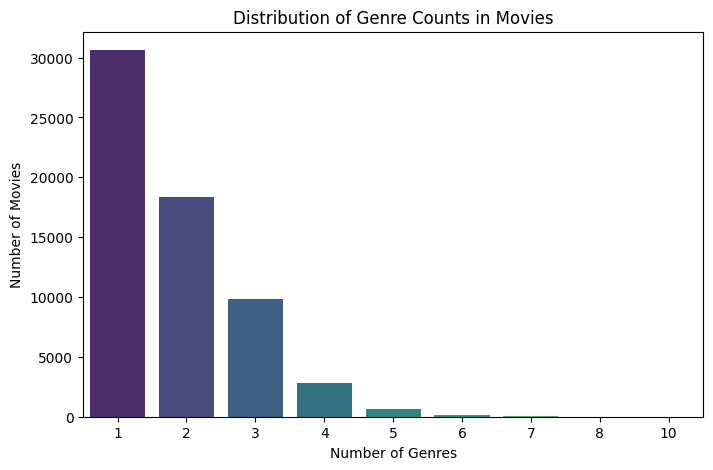

In [6]:
# plot the distribution of genre counts using a barplot and add count labels on top of each bar
plt.figure(figsize=(8, 5))
sns.barplot(x='genre_count', y='movie_count', data=genre_count_distribution, palette='viridis')

plt.xlabel('Number of Genres')
plt.ylabel('Number of Movies')
plt.title('Distribution of Genre Counts in Movies')
plt.show()

**3. Distribution of Movies by Genre**

We split the genres and count how many times each genre appears across all movies.

In [7]:
genre_distribution = (
    movies_df['genres']
    .str.split('|')
    .explode()
    .value_counts()
    .sort_values(ascending=False)
)

# add percentage column
genre_distribution = genre_distribution.reset_index()
genre_distribution.columns = ['genre', 'count']
genre_distribution['percentage'] = (genre_distribution['count'] / genre_distribution['count'].sum() * 100).round(2)


genre_distribution

,genre,count,percentage
0,Drama,25606,22.80
1,Comedy,16870,15.02
2,Thriller,8654,7.71
3,Romance,7719,6.87
4,Action,7348,6.54
5,Horror,5989,5.33
6,Documentary,5605,4.99
7,Crime,5319,4.74
8,(no genres listed),5062,4.51
9,Adventure,4145,3.69


Drama made up the highest genre with 22% or 25,606 movies 

## Distribution of Ratings in the train data


In [8]:
train_df.head()

,userId,movieId,rating,timestamp
0,5163,57669,4.0,1518349992
1,106343,5,4.5,1206238739
2,146790,5459,5.0,1076215539
3,106362,32296,2.0,1423042565
4,9041,366,3.0,833375837


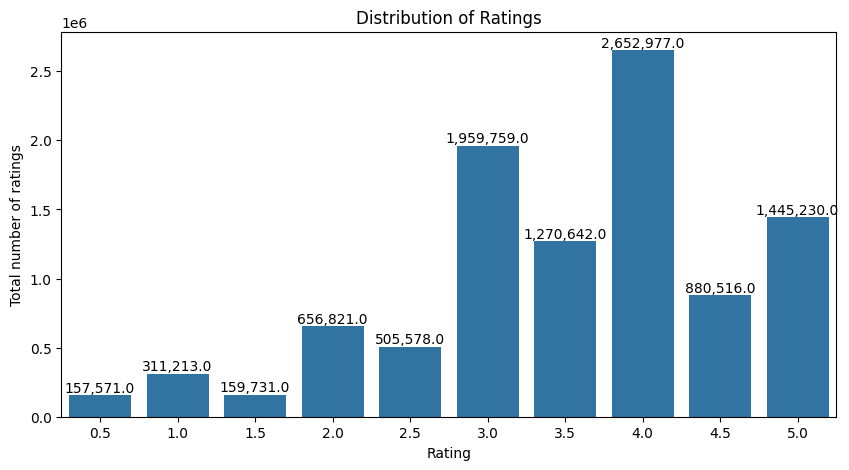

Average rating in dataset: 3.53


In [9]:
# distribution of ratings
rating_dist = (
    train_df['rating']
    .value_counts()
    .sort_index()
    .reset_index()
)

rating_dist.columns = ['rating', 'count']

# add percentage

rating_dist['percentage'] = (
    rating_dist['count'] / rating_dist['count'].sum() * 100
).round(2)


plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=rating_dist,
    x='rating',
    y='count'
)

# Add labels on top of bars
for i, row in rating_dist.iterrows():
    ax.text(
        i,                      # x position
        row['count'],           # y position
        f"{row['count']:,}",    # formatted count (with commas)
        ha='center',
        va='bottom'
    )

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Total number of ratings")

plt.show()

print(f'Average rating in dataset: {np.mean(train_df["rating"]):.2f}')


In [10]:
train_df.columns

Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='str')

# Building the Recommender Engine

The recommender engine is built using **User-Based Collaborative Filtering**. This approach was because the dataset focuses on user ratings rather than movie features.
This approach works on a simple idea:

    If two users have similar tastes, they are likely to enjoy similar movies.

Instead of looking at movie attributes (like genres or actors), we use user behavior (ratings) to make recommendations.

Our goal is to:

- Identify users with similar movie preferences
- Use their ratings to recommend new movies
- Suggest movies a user has not yet watched

**Approach Overview**

The process follows these key steps:

1. Create a User–Item Matrix
    - Rows represent users
    - Columns represent movies
    - Values represent ratings
2. Handle Missing Values
    - Not all users rate all movies
    - Missing values must be addressed before computing similarity
3. Compute User Similarity
    - Measure how similar users are based on their rating patterns
    - Common methods include:
        - Cosine similarity
        - Pearson correlation
4. Identify Similar Users
    - For each user, find the most similar users
5. Generate Recommendations (next step)
    - Recommend movies liked by similar users

User similarity is the foundation of collaborative filtering. This means that:
- If two users rate many movies similarly → they are considered similar
- Recommendations are based on the preferences of these similar users

In [11]:
# attach movie titles to train_df
train_df = train_df.merge(movies_df[['movieId', 'title']], on='movieId', how='left')
train_df.head()

,userId,movieId,rating,timestamp,title
0,5163,57669,4.0,1518349992,In Bruges (2008)
1,106343,5,4.5,1206238739,Father of the Bride Part II (1995)
2,146790,5459,5.0,1076215539,Men in Black II (a.k.a. MIIB) (a.k.a. MIB 2) (...
3,106362,32296,2.0,1423042565,Miss Congeniality 2: Armed and Fabulous (2005)
4,9041,366,3.0,833375837,Wes Craven's New Nightmare (Nightmare on Elm S...


In [12]:
# create User-Item matrix (memory-efficient)
from scipy.sparse import csr_matrix
import gc

# Factorize directly (avoids expensive astype('category') on a 10M+ row frame)
user_codes, user_ids = pd.factorize(train_df['userId'], sort=False)
movie_codes, movie_ids = pd.factorize(train_df['movieId'], sort=False)

# Use compact dtypes to reduce RAM pressure
row_idx = user_codes.astype(np.int32, copy=False)
col_idx = movie_codes.astype(np.int32, copy=False)
ratings = train_df['rating'].to_numpy(dtype=np.float32, copy=False)

user_item_matrix = csr_matrix(
    (ratings, (row_idx, col_idx)),
    shape=(len(user_ids), len(movie_ids)),
    dtype=np.float32,
)

# Cleanup temporary arrays
for var_name in ['user_codes', 'movie_codes', 'row_idx', 'col_idx', 'ratings']:
    del globals()[var_name]
gc.collect()

print(f"Users: {len(user_ids):,}, Movies: {len(movie_ids):,}")
user_item_matrix.shape

Users: 162,541, Movies: 48,213


(162541, 48213)

**Utility Matrix Heatmap (Sampled)**

A full user-movie utility matrix is too large to visualize directly, so we create a neat-title version on a sampled subset for plotting.

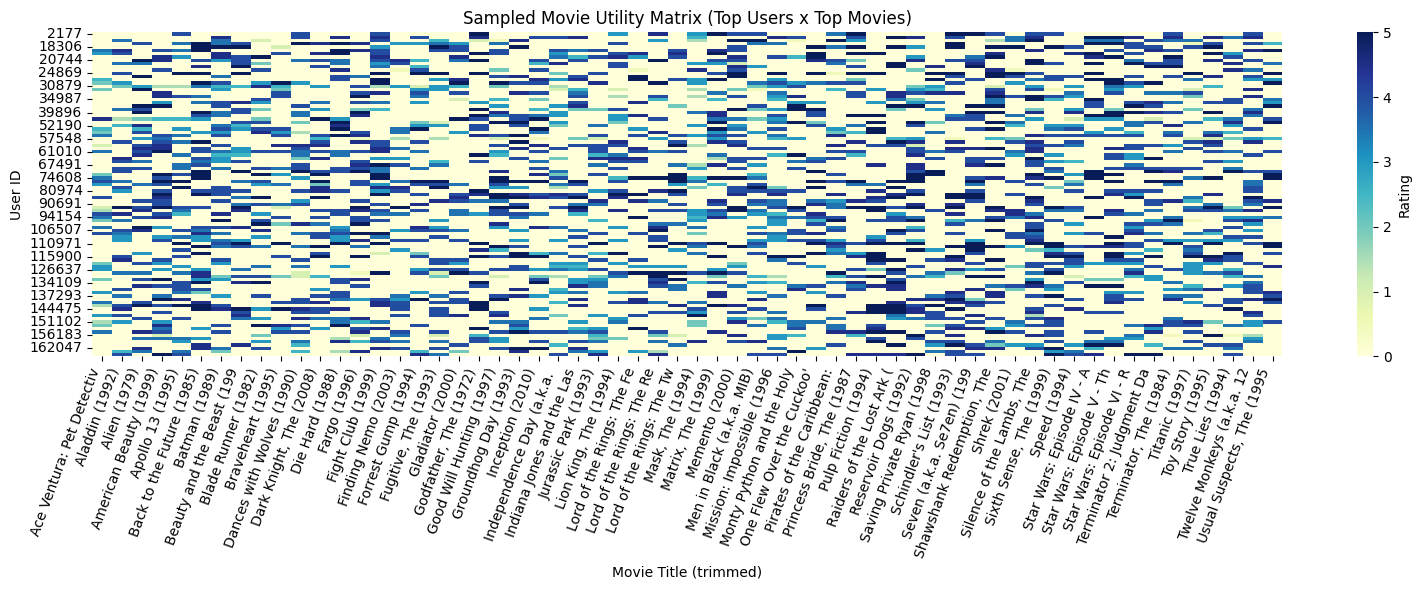

Heatmap matrix shape: (99, 60)


In [13]:
# Create a neat utility matrix for visualization
# If title is not present in train_df, merge it from movies_df.
if 'title' not in train_df.columns:
    plot_df = train_df.merge(movies_df[['movieId', 'title']], on='movieId', how='left')
else:
    plot_df = train_df[['userId', 'movieId', 'rating', 'title']].copy()

plot_df['neat_title'] = plot_df['title'].fillna('Unknown').str.slice(0, 25)

# Keep this small enough for plotting.
# We choose active users and popular movies to get a dense, readable heatmap.
top_users = plot_df['userId'].value_counts().head(100).index
top_movies = plot_df['movieId'].value_counts().head(60).index

plot_subset = plot_df[
    plot_df['userId'].isin(top_users) & plot_df['movieId'].isin(top_movies)
].copy()

util_matrix_neat = plot_subset.pivot_table(
    index='userId',
    columns='neat_title',
    values='rating',
    aggfunc='mean',
)

plt.figure(figsize=(16, 6))
sns.heatmap(
    util_matrix_neat.fillna(0),
    cmap='YlGnBu',
    cbar_kws={'label': 'Rating'}
)
plt.title('Sampled Movie Utility Matrix (Top Users x Top Movies)')
plt.xlabel('Movie Title (trimmed)')
plt.ylabel('User ID')
plt.xticks(rotation=70, ha='right')
plt.tight_layout()
plt.show()

print('Heatmap matrix shape:', util_matrix_neat.shape)

**Compute User Similarity**

We explore how simila users are. we startt by normalizing the data. Since we used crs sparse matrix we adopt the Mean-centering; a lightweight and scalable method


In [14]:
# compute user mean ratings
user_means = np.array(user_item_matrix.mean(axis=1)).flatten()

# subtract mean (center ratings)
row_indices, col_indices = user_item_matrix.nonzero()
user_item_matrix.data -= user_means[row_indices]

In [15]:
# compute similarity
from sklearn.neighbors import NearestNeighbors

model_knn = NearestNeighbors(metric='cosine', algorithm='brute')
model_knn.fit(user_item_matrix)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'brute'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


Now we build the recommender function

In [16]:
def recommend_movies(user_id, n_recommendations = 10, n_neighbors = 10):

    """
    Generate movies recommendations for a given user using user-based collaborative filtering with nearest neighbors.

    This function identifies users with similar rating patterns and recommends movies that those similar users have liked, excluding movies already watched by the target user.
    
    Parameters:
    ------------
    user_id (int): The ID of the user for whom to generate recommendations.
    n_recommendations (int): The number of movie recommendations to return. Default is 10.
    n_meighbors (int): The number of nearest neighbors to consider when generating recommendations. Default is 10.

    Returns:
    ------------
    list
        A list of recommended movie IDs ranked by relevance.

    Notes
    -----
    - Uses cosine similarity via NearestNeighbors model.
    - Assumes `user_item_matrix`, `user_ids`, `movie_ids`,
      and `model_knn` are precomputed and available globally.
    
    """

    # Get user index
    user_idx = np.where(user_ids == user_id)[0][0]

    # find similar users
    distances, indices = model_knn.kneighbors(
        user_item_matrix[user_idx],
        n_neighbors=n_neighbors + 1
    )

    similar_users = indices.flatten()[1:]  # Exclude the user itself

    # Aggregate movie scores
    movie_scores = {}

    for sim_user in similar_users:
        sim_user_ratings = user_item_matrix[sim_user].toarray().flatten()
        
        for movie_idx, rating in enumerate(sim_user_ratings):
            if rating > 0:  # Consider only positively rated movies
                if movie_idx not in movie_scores:
                    movie_scores[movie_idx] = 0
                movie_scores[movie_idx] += rating
    
    # Rank movies by score
    ranked_movies = sorted(
        movie_scores.items(),
        key = lambda x: x[1],
        reverse=True
    )

    # convert to movie IDs
    recommended_movie_ids = [
        movie_ids[movie_idx] for movie_idx, _ in ranked_movies[:n_recommendations]
    ]

    return recommended_movie_ids


## Predict Ratings For test_df Using User-Based CF

Your `recommend_movies` function returns top-N movie IDs.
For Kaggle submission, we need a predicted **rating** for each `(userId, movieId)` pair in `test_df`.

The next cell adds a weighted-neighbor predictor and applies it to test data.

In [17]:
# Setup: user-based CF rating prediction helpers
from pathlib import Path

# Fast lookup maps
user_to_idx = {uid: i for i, uid in enumerate(user_ids)}
movie_to_idx = {mid: i for i, mid in enumerate(movie_ids)}

# Fallback for unseen users/movies or no neighbor signal
global_mean = float(train_df['rating'].mean())

# Cache nearest neighbors per user index to avoid repeated KNN calls
neighbor_cache = {}

def get_neighbors_with_similarity(user_idx, n_neighbors=10):
    if user_idx in neighbor_cache:
        return neighbor_cache[user_idx]

    n_users = user_item_matrix.shape[0]
    k = min(n_neighbors + 1, n_users)  # +1 includes the user itself
    distances, indices = model_knn.kneighbors(user_item_matrix[user_idx], n_neighbors=k)

    neighbors = indices.flatten()[1:]
    similarities = 1.0 - distances.flatten()[1:]  # cosine similarity

    neighbor_cache[user_idx] = (neighbors, similarities)
    return neighbors, similarities

def predict_rating_user_cf(user_id, movie_id, n_neighbors=10, default_rating=None):
    """Predict one rating for a (userId, movieId) pair using weighted user neighbors."""
    if default_rating is None:
        default_rating = global_mean

    u_idx = user_to_idx.get(user_id, None)
    m_idx = movie_to_idx.get(movie_id, None)

    # Cold-start fallback
    if u_idx is None or m_idx is None:
        return float(default_rating)

    neighbors, sims = get_neighbors_with_similarity(u_idx, n_neighbors=n_neighbors)
    if len(neighbors) == 0:
        return float(default_rating)

    # Ratings given by neighbors for this target movie
    neighbor_ratings = user_item_matrix[neighbors, m_idx].toarray().ravel()

    # Keep neighbors that rated this movie
    rated_mask = neighbor_ratings > 0
    if not rated_mask.any():
        return float(default_rating)

    r = neighbor_ratings[rated_mask]
    w = sims[rated_mask]

    # Weighted mean; if weights collapse, use simple mean
    w_sum = np.abs(w).sum()
    if w_sum > 1e-12:
        pred = float(np.dot(r, w) / w_sum)
    else:
        pred = float(r.mean())

    # Ratings are bounded in this competition
    return float(np.clip(pred, 0.5, 5.0))

print('Prediction helpers ready. Run the next cell to score test_df and save submission.')

Prediction helpers ready. Run the next cell to score test_df and save submission.


In [ ]:
# Run scoring on test_df in chunks with resume support, checkpoints, and final report
from pathlib import Path
from tqdm.auto import tqdm
import time

# Max rows per chunk that your machine can handle safely
chunk_size = 25_000
n_neighbors = 10

total_rows = len(test_df)
total_chunks = (total_rows + chunk_size - 1) // chunk_size

project_root = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
submissions_dir = project_root / 'submissions'
submissions_dir.mkdir(parents=True, exist_ok=True)

# Each chunk gets its own checkpoint file for safe resume after crashes
checkpoints_dir = submissions_dir / 'user_cf_checkpoints'
checkpoints_dir.mkdir(parents=True, exist_ok=True)

cf_output_path = submissions_dir / 'user_cf_submission.csv'

print(f"Scoring test_df in chunks of {chunk_size:,} rows. Total rows: {total_rows:,} ({total_chunks} chunks)")
print(f"Checkpoint folder: {checkpoints_dir}")

# Build chunk ranges once so ordering is deterministic when we combine files
chunk_ranges = [
    (chunk_idx, start, min(start + chunk_size, total_rows))
    for chunk_idx, start in enumerate(range(0, total_rows, chunk_size), start=1)
]

existing_count = 0
for chunk_idx, _, _ in chunk_ranges:
    chunk_path = checkpoints_dir / f'user_cf_chunk_{chunk_idx:04d}.csv'
    if chunk_path.exists():
        existing_count += 1

print(f"Existing checkpoints found: {existing_count}/{total_chunks}")

scored_now = 0
chunk_times = []

for chunk_idx, start, end in tqdm(chunk_ranges, desc='Scoring chunks'):
    chunk_path = checkpoints_dir / f'user_cf_chunk_{chunk_idx:04d}.csv'

    # Resume support: skip chunks that were already saved previously
    if chunk_path.exists():
        continue

    score_df = test_df.iloc[start:end].copy()

    t0 = time.perf_counter()
    predictions = np.empty(len(score_df), dtype=np.float32)

    for i, (u, m) in enumerate(zip(score_df['userId'].values, score_df['movieId'].values)):
        predictions[i] = predict_rating_user_cf(
            user_id=u,
            movie_id=m,
            n_neighbors=n_neighbors,
            default_rating=global_mean
        )

    chunk_pred_df = score_df[['userId', 'movieId']].copy()
    chunk_pred_df['rating'] = predictions
    chunk_pred_df['Id'] = (
        chunk_pred_df['userId'].astype(str) + '_' + chunk_pred_df['movieId'].astype(str)
    )

    # Save per-chunk checkpoint (keeps user/movie columns for reporting)
    chunk_pred_df.to_csv(chunk_path, index=False)

    elapsed = time.perf_counter() - t0
    chunk_times.append(elapsed)
    scored_now += 1

    avg_time = float(np.mean(chunk_times))
    done_total = existing_count + scored_now
    remaining = max(total_chunks - done_total, 0)
    eta_seconds = remaining * avg_time
    rows_per_sec = len(score_df) / elapsed if elapsed > 0 else float('inf')

    print(
        f"[chunk {chunk_idx}/{total_chunks}] rows={len(score_df):,} "
        f"time={elapsed:.1f}s speed={rows_per_sec:,.0f} rows/s "
        f"done={done_total}/{total_chunks} eta~{eta_seconds/60:.1f} min"
    )

# Combine all checkpoint files in chunk order
chunk_frames = []
missing_chunks = []

for chunk_idx, _, _ in chunk_ranges:
    chunk_path = checkpoints_dir / f'user_cf_chunk_{chunk_idx:04d}.csv'
    if chunk_path.exists():
        cdf = pd.read_csv(chunk_path)

        # Backward compatibility if an old checkpoint has only Id and rating
        if 'userId' not in cdf.columns or 'movieId' not in cdf.columns:
            id_parts = cdf['Id'].astype(str).str.split('_', n=1, expand=True)
            cdf['userId'] = pd.to_numeric(id_parts[0], errors='coerce')
            cdf['movieId'] = pd.to_numeric(id_parts[1], errors='coerce')

        chunk_frames.append(cdf)
    else:
        missing_chunks.append(chunk_idx)

if missing_chunks:
    print(f"Missing {len(missing_chunks)} chunk checkpoint(s).")
    print('Final submission not saved yet. Re-run this cell to finish missing chunks.')
else:
    full_pred_df = pd.concat(chunk_frames, ignore_index=True)
    submission_cf = full_pred_df[['Id', 'rating']].copy()
    submission_cf.to_csv(cf_output_path, index=False)

    print('Saved CF submission to:', cf_output_path)
    print('Submission shape:', submission_cf.shape)

    # Short final report for submission sanity checks
    total_users = int(full_pred_df['userId'].nunique())
    total_movies = int(full_pred_df['movieId'].nunique())
    avg_rec_by_user = float(full_pred_df.groupby('userId', sort=False)['rating'].mean().mean())
    avg_rec_by_movie = float(full_pred_df.groupby('movieId', sort=False)['rating'].mean().mean())
    highest_rec = float(full_pred_df['rating'].max())
    lowest_rec = float(full_pred_df['rating'].min())

    print('\nSubmission Summary Report')
    print('-------------------------')
    print(f'Total prediction rows: {len(full_pred_df):,}')
    print(f'Total users: {total_users:,}')
    print(f'Total movies: {total_movies:,}')
    print(f'Average recommendation by user: {avg_rec_by_user:.4f}')
    print(f'Average recommendation by movie: {avg_rec_by_movie:.4f}')
    print(f'Highest recommendation: {highest_rec:.4f}')
    print(f'Lowest recommendation: {lowest_rec:.4f}')

    submission_cf.head()

Scoring first 25,000 rows (set max_rows=None for full test_df).


Predicting test ratings: 100%|██████████| 25000/25000 [02:38<00:00, 158.15it/s] 


Saved CF submission to: C:\Users\leboo\OneDrive\Documents\ALX learning\Data Science\Machine Learning\3. Unsupervised Learning\11. Kaggle Project - Recommender systems\submissions\user_cf_submission.csv


,Id,rating
0,1_2011,3.533395
1,1_4144,3.533395
2,1_5767,3.533395
3,1_6711,3.533395
4,1_7318,3.533395


Test the recommender

In [19]:
# pick a user and get recommendations
test_user = train_df['userId'].iloc[0]
test_user

np.int64(5163)

In [20]:
recommendations = recommend_movies(
    user_id=test_user,
    n_recommendations=10,
    n_neighbors=10
)

recommendations

[np.int64(1210),
 np.int64(50),
 np.int64(1270),
 np.int64(2571),
 np.int64(2502),
 np.int64(223),
 np.int64(1196),
 np.int64(7153),
 np.int64(1968),
 np.int64(68157)]

View results in a readable format

In [21]:
movies_df[movies_df['movieId'].isin(recommendations)]

,movieId,title,genres,genre_count
49,50,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,3
220,223,Clerks (1994),Comedy,1
1166,1196,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi,3
1179,1210,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Sci-Fi,3
1237,1270,Back to the Future (1985),Adventure|Comedy|Sci-Fi,3
1879,1968,"Breakfast Club, The (1985)",Comedy|Drama,2
2411,2502,Office Space (1999),Comedy|Crime,2
2480,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,3
7028,7153,"Lord of the Rings: The Return of the King, The...",Action|Adventure|Drama|Fantasy,4
13249,68157,Inglourious Basterds (2009),Action|Drama|War,3


Compare with user history

Let’s check what the user has already watched:

In [22]:
watched_movies = train_df[train_df['userId'] == test_user]['movieId'].unique()
watched_movies

array([57669, 68157,  1247,   441,  2671,    50,  1394,  2167,   380,
        7361, 96811,  1270,  2571, 51255,   344,  1952,   223,  2502,
        3052,  1210,  1968, 54272])

In [23]:
# remove Remove Already Watched Movies from Recommendations
final_recommendations = [
    movie_id for movie_id in recommendations
    if movie_id not in watched_movies
]

In [24]:
# display the final recommendations
clean_movies = movies_df.drop_duplicates(subset=['movieId'])

recommended_movies = clean_movies[
    clean_movies['movieId'].isin(final_recommendations)
][['movieId', 'title', 'genres']]

recommended_movies


,movieId,title,genres
1166,1196,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi
7028,7153,"Lord of the Rings: The Return of the King, The...",Action|Adventure|Drama|Fantasy


In [25]:
recommendations

[np.int64(1210),
 np.int64(50),
 np.int64(1270),
 np.int64(2571),
 np.int64(2502),
 np.int64(223),
 np.int64(1196),
 np.int64(7153),
 np.int64(1968),
 np.int64(68157)]

## Evaluate the recommendation engine



### Create a Simple Baseline Model

We start simple: Global average baseline

In [41]:
global_mean = train_df['rating'].mean()
global_mean

np.float64(3.5333951730983424)

### Predict for test set (baseline submission)

We start with the simplest prediction:

Every user-movie pair = global mean rating

In [42]:
test_df['rating']= global_mean

### Create submission file

In [44]:
submission = test_df[['userId', 'movieId', 'rating']]
submission.head()

,userId,movieId,rating
0,1,2011,3.533395
1,1,4144,3.533395
2,1,5767,3.533395
3,1,6711,3.533395
4,1,7318,3.533395


### Save submission file

In [45]:
# Save submission file to submissions folder
from pathlib import Path

project_root = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
submissions_dir = project_root / 'submissions'
submissions_dir.mkdir(parents=True, exist_ok=True)

submission_to_save = submission.copy()

# Ensure Kaggle-required format: Id,rating where Id = userId_movieId
if {'userId', 'movieId', 'rating'}.issubset(submission_to_save.columns):
    submission_to_save['Id'] = (
        submission_to_save['userId'].astype(str)
        + '_'
        + submission_to_save['movieId'].astype(str)
    )
    submission_to_save = submission_to_save[['Id', 'rating']]

output_path = submissions_dir / 'baseline_submission.csv'
submission_to_save.to_csv(output_path, index=False)

print(f'Saved submission to: {output_path}')
submission_to_save.head()

Saved submission to: C:\Users\leboo\OneDrive\Documents\ALX learning\Data Science\Machine Learning\3. Unsupervised Learning\11. Kaggle Project - Recommender systems\submissions\baseline_submission.csv


,Id,rating
0,1_2011,3.533395
1,1_4144,3.533395
2,1_5767,3.533395
3,1_6711,3.533395
4,1_7318,3.533395


### We move to upgrade the evaluation system

**RMSE-Based Recommender Modeling Roadmap**

We will implement:

✔ Model 1: Baseline (Global Mean)
✔ Model 2: User + Item Mean (Simple upgrade)
✔ Model 3: User-Based Collaborative Filtering (your current work)
✔ Model 4: Matrix Factorization (SVD — best performing)

We go step by step.

STEP 1: RMSE Function (we will reuse this)

Before models, define evaluation:

In [46]:
from sklearn.metrics import mean_squared_error

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

Baseline Model (Global Mean)

Everyone gets the same rating

In [47]:
global_mean = train_df['rating'].mean()

baseline_pred = np.full(len(test_df), global_mean)

baseline_pred[:5]

array([3.53339517, 3.53339517, 3.53339517, 3.53339517, 3.53339517])

Evaluate with true ratings in test df

In [48]:
rmse(test_df['rating'], baseline_pred)

np.float64(0.0)

User Mean + Movie Mean (Better baseline)

Some users rate high, some movies are popular

In [51]:
# compute means
user_mean = train_df.groupby('userId', sort=False)['rating'].mean().astype(np.float32)
movie_mean = train_df.groupby('movieId', sort=False)['rating'].mean().astype(np.float32)

# Vectorized prediction (memory-safe vs row-wise apply)
global_mean_f = np.float32(global_mean)

user_pred = test_df['userId'].map(user_mean)
movie_pred = test_df['movieId'].map(movie_mean)

u = user_pred.to_numpy(dtype=np.float32, na_value=np.nan)
m = movie_pred.to_numpy(dtype=np.float32, na_value=np.nan)

pred = np.full(test_df.shape[0], global_mean_f, dtype=np.float32)

u_ok = ~np.isnan(u)
m_ok = ~np.isnan(m)

both = u_ok & m_ok
only_u = u_ok & ~m_ok
only_m = ~u_ok & m_ok

pred[both] = (u[both] + m[both]) / np.float32(2.0)
pred[only_u] = u[only_u]
pred[only_m] = m[only_m]

test_df['pred_rating'] = pred

# evaluate (only if ground truth exists)
if 'rating' in test_df.columns:
    print('RMSE:', rmse(test_df['rating'], test_df['pred_rating']))
else:
    print('No rating column in test_df; predictions created in test_df["pred_rating"].')

RMSE: 0.3619536033673569


User-Based Collaborative Filtering (our model)

Now we upgrade the recommender into prediction form.


- Predict based on similar users’ ratings

In [54]:
# User-based CF prediction with sparse cosine + caching (no DataFrame apply)
# This avoids heavy kneighbors allocations on the full matrix.

from tqdm.auto import tqdm
import gc

user_index = pd.Index(user_ids)
movie_index = pd.Index(movie_ids)

k = 10
max_eval_rows = 100_000  # set to None for full set (can be very slow)

if max_eval_rows is not None and len(test_df) > max_eval_rows:
    eval_df = test_df.sample(max_eval_rows, random_state=42).copy()
else:
    eval_df = test_df.copy()

u_idx = user_index.get_indexer(eval_df['userId'])
m_idx = movie_index.get_indexer(eval_df['movieId'])

pred_cf = np.full(len(eval_df), np.float32(global_mean), dtype=np.float32)
valid = (u_idx >= 0) & (m_idx >= 0)

neighbor_cache = {}


def get_neighbors_sparse(u, top_k=10):
    if u in neighbor_cache:
        return neighbor_cache[u]

    # Sparse output helps avoid dense allocations.
    sims = cosine_similarity(user_item_matrix[u], user_item_matrix, dense_output=False)
    sim_idx = sims.indices
    sim_val = sims.data

    # Remove self-similarity if present.
    keep = sim_idx != u
    sim_idx = sim_idx[keep]
    sim_val = sim_val[keep]

    if sim_idx.size == 0:
        neighbor_cache[u] = np.array([], dtype=np.int32)
        return neighbor_cache[u]

    if sim_idx.size > top_k:
        top = np.argpartition(sim_val, -top_k)[-top_k:]
        # sort selected neighbors by similarity descending
        top = top[np.argsort(sim_val[top])[::-1]]
        neighbors = sim_idx[top].astype(np.int32, copy=False)
    else:
        order = np.argsort(sim_val)[::-1]
        neighbors = sim_idx[order].astype(np.int32, copy=False)

    neighbor_cache[u] = neighbors
    return neighbors


valid_positions = np.where(valid)[0]
for pos in tqdm(valid_positions, desc='Scoring CF rows'):
    u = u_idx[pos]
    m = m_idx[pos]

    neighbors = get_neighbors_sparse(u, top_k=k)
    if neighbors.size == 0:
        continue

    vals = user_item_matrix[neighbors, m].toarray().ravel()
    vals = vals[vals > 0]

    if vals.size > 0:
        pred_cf[pos] = np.float32(vals.mean())

eval_df['pred_cf'] = pred_cf

gc.collect()

if 'rating' in eval_df.columns:
    print('Rows scored:', len(eval_df))
    print('CF RMSE:', rmse(eval_df['rating'], eval_df['pred_cf']))
else:
    print('No rating column in eval_df. Predictions available in eval_df["pred_cf"].')

eval_df[['userId', 'movieId', 'pred_cf']].head()

Scoring CF rows:   4%|▎         | 3713/99870 [15:18<6:36:17,  4.04it/s] 


MemoryError: Unable to allocate 38.1 MiB for an array with shape (10000038,) and data type float32